# Clinical sequencing

Real-world clinical surveillance sequences a single sample from a single patient, in contrast with the population-level lens granted by `WastewaterSampler`. `ClinicalSequencer` is a `cv.Analyzer` that mimics this: on specified days it draws a fixed number
of agents from a chosen pool (`infectious`, `symptomatic`, or `diagnosed`),
and records each sampled agent's haplotype relative to the
simulation reference genome.

This notebook introduces three SARS-CoV-2 variants in sequence
(AY.4 → BA.2 → XBB.1.5) and compares clinical sequencing against
`WastewaterSampler` — the population-level analyzer covered in
[`tut_wastewater.ipynb`](tut_wastewater.ipynb).

It covers:

1. **Setup** — variants, three `ClinicalSequencer` configurations, and a
   `WastewaterSampler` run side by side.
2. **Routine surveillance** — n=50 symptomatic agents sequenced every 10 days,
   released immediately.
3. **Batch sequencing** — the same collection rate, but specimens queue until
   a flow-cell-sized batch (96) is ready before being released.
4. **Clinical vs. true proportions** — how well a small clinical sample
   estimates the actual variant mix circulating in the full population.
5. **Surge sampling** — a variable per-day sampling schedule (the `days` dict
   interface) with a larger n on two peak days, plus a haplotype-diversity
   check.
6. **FASTA export** — turning a day's clinical sample into a multi-FASTA
   string for downstream tools.

> **Note:** FASTA files are read from `sars-2-data/` relative to this
> notebook. Run it from the `docs/tutorials/` directory.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import covasim as cv

# Paths are relative to docs/tutorials/ — run the notebook from that directory.
ref_fasta   = 'sars-2-data/NC_045512_Hu-1.fasta'
fitness_csv = '../../data/nt_fitness.csv'
ay4_fasta   = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta   = 'sars-2-data/variants/BA.2.9_consensus.fasta'
xbb15_fasta = 'sars-2-data/variants/XBB.1.5.18_consensus.fasta'


Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


## Setup: variants and analyzers

Three variants are imported in turn — AY.4 (day 30), BA.2 (day 70), and
XBB.1.5 (day 110) — each seeded from a consensus FASTA so its founding
mutations (and hence Bloom-derived fitness) are set automatically by
`evo_pars`, rather than a hand-tuned `rel_beta`.

Four analyzers run over the same simulation so their outputs are directly
comparable:

- `cs_routine` — routine clinical surveillance: n=50 symptomatic agents every
  10 days, released the same day (`sequencing_batch_size=1`, the default).
- `cs_batched` — the same collection schedule, but specimens sit in a FIFO
  queue and are only released once 96 have accumulated (a sequencing flow
  cell), which delays and lumps the release days.
- `cs_surge` — a variable-count schedule using the `days` dict interface:
  200 sequences on two chosen peak days instead of a fixed n per day.
- `ww` — `WastewaterSampler`, for a population-level baseline (see
  `tut_wastewater.ipynb` for a deep dive on this analyzer).

In [ ]:
ay4 = cv.variant(
    variant        = {},
    label          = 'AY.4',
    days           = 30,
    n_imports      = 60,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    variant        = {},
    label          = 'BA.2',
    days           = 70,
    n_imports      = 60,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 110,
    n_imports      = 60,
    founding_fasta = xbb15_fasta,
)

sample_days = list(range(90, 181, 10))

# Routine clinical: 50 symptomatic agents per day, every 10 days.
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 50,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

# Batch sequencing: collect 50/day but only release when 96 specimens queued.
cs_batched = cv.ClinicalSequencer(
    days                  = sample_days,
    n_samples             = 50,
    pool                  = 'symptomatic',
    sequencing_batch_size = 96,
    label                 = 'CS_batched',
)

# Surge sampling: variable counts on two peak days using the dict interface.
cs_surge = cv.ClinicalSequencer(
    days  = {120: 200, 150: 200},
    pool  = 'symptomatic',
    label = 'CS_surge',
)

# Wastewater sampler for side-by-side comparison.
ww = cv.WastewaterSampler(days=sample_days, label='WW')

sim = cv.Sim(
    dict(
        pop_size     = 25_000,
        pop_infected = 30,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
        rand_seed    = 42,
        n_imports    = 0,
        evo_pars = dict(
            enable            = True,
            reference         = ref_fasta,
            mol_clock_rate    = 1e-6,
            fitness_model     = 'bloom_nt',
            fitness_data_path = fitness_csv,
            fitness_scale     = 0.05,
        ),
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine, cs_batched, cs_surge, ww],
    verbose   = 0,
)
sim.run()

# Retrieve live analyzer instances (Covasim deep-copies on initialization)
cs_routine = sim.get_analyzer('CS_routine')
cs_batched = sim.get_analyzer('CS_batched')
cs_surge   = sim.get_analyzer('CS_surge')
ww         = sim.get_analyzer('WW')

variant_names = list(sim['variant_map'].values())
n_inf         = sim.results['variant']['n_infectious_by_variant'].values
total         = n_inf.sum(axis=0)
total[total == 0] = 1
props = {v: n_inf[i] / total for i, v in enumerate(variant_names)}

print('Done.')

/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/AY.4_consensus.fasta" length (29890) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(
/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/BA.2.9_consensus.fasta" length (29743) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(
/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/XBB.1.5.18_consensus.fasta" length (29749) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(


Done.


## Routine clinical sequencing

For each release day, we tally what fraction of the 50 sequenced agents
carried each variant label — this is exactly what a public-health lab would
report from a routine surveillance sample.

In [3]:
def variant_counts(samples):
    '''Count how many sampled agents carry each variant label.'''
    counts = {}
    for s in samples:
        counts[s.variant_label] = counts.get(s.variant_label, 0) + 1
    return counts


print('Routine clinical sequencing (n=50/day, pool=symptomatic, immediate release):')
header = f'  {"Release":>7}  {"Date":>12}  {"N seq":>6}  ' + \
         '  '.join(f'{v:>10}' for v in variant_names)
print(header)
print('  ' + '-' * (len(header) - 2))

for day in sorted(cs_routine.samples):
    batch = cs_routine.samples[day]
    if not batch:
        print(f'  {day:>7}  {sim.date(day):>12}  {"—":>6}')
        continue
    counts = variant_counts(batch)
    n = len(batch)
    cols = '  '.join(
        f'{counts.get(v, 0) / n:>9.1%}' for v in variant_names
    )
    print(f'  {day:>7}  {sim.date(day):>12}  {n:>6}  {cols}')

Routine clinical sequencing (n=50/day, pool=symptomatic, immediate release):
  Release          Date   N seq        wild        AY.4        BA.2     XBB.1.5
  -----------------------------------------------------------------------------
       90    2022-11-30      50      26.0%      72.0%       2.0%       0.0%
      100    2022-12-10      50      18.0%      76.0%       6.0%       0.0%
      110    2022-12-20      50       6.0%      70.0%      24.0%       0.0%
      120    2022-12-30      50       6.0%      40.0%      40.0%      14.0%
      130    2023-01-09      50       4.0%      30.0%      30.0%      36.0%
      140    2023-01-19      50       0.0%       6.0%      22.0%      72.0%
      150    2023-01-29      50       0.0%       0.0%       6.0%      94.0%
      160    2023-02-08      50       0.0%       0.0%       8.0%      92.0%
      170    2023-02-18      50       0.0%       0.0%       6.0%      94.0%
      180    2023-02-28      50       0.0%       0.0%       0.0%     100.0%


## Batch sequencing

With `sequencing_batch_size=96`, specimens collected on each sampling day
queue up in a FIFO buffer instead of being released immediately. A release
only fires once the buffer holds a full batch, so release days no longer
line up one-to-one with collection days — this models a lab that waits to
fill a flow cell before running it.

In [4]:
print('Batch sequencing (collect 50/day, release at 96 specimens):')
print(f'  Release events: {len(cs_batched.samples)}')
print(f'  Pending (discarded at end): {cs_batched.n_pending}')
for day in sorted(cs_batched.samples):
    batch = cs_batched.samples[day]
    print(f'  Release day {day:>3} ({sim.date(day)}): {len(batch)} sequences')

Batch sequencing (collect 50/day, release at 96 specimens):
  Release events: 5
  Pending (discarded at end): 20
  Release day 100 (2022-12-10): 96 sequences
  Release day 120 (2022-12-30): 96 sequences
  Release day 140 (2023-01-19): 96 sequences
  Release day 160 (2023-02-08): 96 sequences
  Release day 180 (2023-02-28): 96 sequences


## Clinical sample vs. true simulation proportions

A clinical sample of n=50 is a noisy estimate of the variant mix actually
circulating in the full population. We compare the routine sample on one
focus day against `sim.results['variant']['n_infectious_by_variant']`, which
reflects every infectious agent in the simulation.

In [5]:
focus_day = 120
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

Day 120 (2022-12-30) — clinical estimate vs true simulation proportions:
  Variant        Clinical (n=50)    True (sim)      Diff
  --------------------------------------------------------
  wild                      6.0%         15.6%    -9.6%
  AY.4                     40.0%         40.0%  +   0.0%
  BA.2                     40.0%         29.7%  +  10.3%
  XBB.1.5                  14.0%         14.8%    -0.8%


## Surge sampling and haplotype diversity

`cs_surge` uses the dict form of `days` to sequence 200 agents (instead of a
fixed n every day) on two chosen peak days. Beyond the variant-label
breakdown, we can also check haplotype diversity within the sample — how
many *distinct* mutation sets appear among the sequenced agents, which is a
proxy for how much within-variant evolution has accumulated.

In [6]:
surge_batch = cs_surge.samples.get(120, [])
if surge_batch:
    n_surge = len(surge_batch)
    print(f'Surge sample — day 120 ({sim.date(120)}): {n_surge} agents sequenced')
    counts = variant_counts(surge_batch)
    print('  Variant breakdown:')
    for v, c in sorted(counts.items(), key=lambda x: -x[1]):
        print(f'    {v:12s}: {c:4d}  ({c / n_surge:.1%})')

    unique_haplotypes = len({s.mutations for s in surge_batch})
    print(f'  Unique haplotypes in sample: {unique_haplotypes} / {n_surge}')

Surge sample — day 120 (2022-12-30): 200 agents sequenced
  Variant breakdown:
    AY.4        :   97  (48.5%)
    BA.2        :   61  (30.5%)
    XBB.1.5     :   23  (11.5%)
    wild        :   19  (9.5%)
  Unique haplotypes in sample: 109 / 200


## FASTA export

`to_fasta(day)` reconstructs each sampled agent's full ACGT sequence from its
mutation set and the reference genome, returning a ready-to-use multi-FASTA
string — the same interface `WastewaterSampler` exposes, so clinical and
wastewater sequences can be compared or combined downstream.

In [7]:
if cs_batch:
    fasta_str = cs_routine.to_fasta(focus_day)
    fasta_out = f'clinical_day{focus_day}.fasta'
    with open(fasta_out, 'w') as fh:
        fh.write(fasta_str + '\n')
    print(f'Saved clinical FASTA -> {fasta_out}')
    print(f'  ({len(cs_batch)} sequences, {len(fasta_str)} characters)')
    print('\nFirst two FASTA records:')
    for line in fasta_str.split('\n')[:4]:
        print(' ', line[:100])

Saved clinical FASTA -> clinical_day120.fasta
  (50 sequences, 1497845 characters)

First two FASTA records:
  >agent_1804  day=120  date=2022-12-30  variant=AY.4
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC
  >agent_24592  day=120  date=2022-12-30  variant=BA.2
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC


## Plot: true dynamics vs. clinical sequencing estimates

The top panel shows the true, population-level variant proportions over
time (from `sim.results['variant']['n_infectious_by_variant']`); the bottom
panel shows what routine clinical sequencing (n=50/day) actually observed on
each release day. Dotted vertical lines mark each variant's introduction
day.

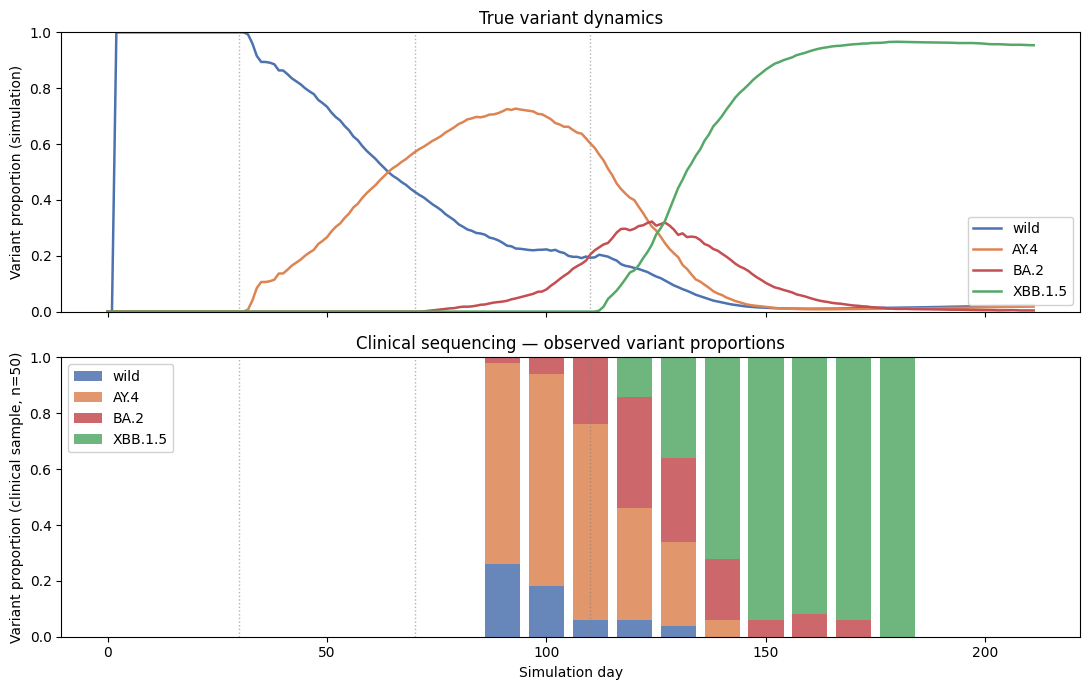

In [8]:
palette = {
    'wild'   : '#4C72B0',
    'AY.4'   : '#DD8452',
    'BA.2'   : '#C44E52',
    'XBB.1.5': '#55A868',
}
_defaults = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, v in enumerate(variant_names):
    palette.setdefault(v, _defaults[i % len(_defaults)])

days_with_data = sorted(d for d, batch in cs_routine.samples.items() if batch)
clin_props_by_variant = {v: [] for v in variant_names}
for day in days_with_data:
    batch = cs_routine.samples[day]
    counts = variant_counts(batch)
    n = len(batch)
    for v in variant_names:
        clin_props_by_variant[v].append(counts.get(v, 0) / n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
tvec = np.arange(sim.npts)

# Top panel: true simulation dynamics
for v in variant_names:
    ax1.plot(tvec, props[v], label=v, color=palette[v], linewidth=1.8)
for d in [30, 70, 110]:
    ax1.axvline(d, color='grey', linestyle=':', linewidth=1.0, alpha=0.6)
ax1.set_ylabel('Variant proportion (simulation)')
ax1.set_title('True variant dynamics')
ax1.legend(framealpha=0.9)
ax1.set_ylim(0, 1)

# Bottom panel: clinical sequencing estimates
x = np.array(days_with_data)
bottom = np.zeros(len(x))
for v in variant_names:
    y = np.array(clin_props_by_variant[v])
    ax2.bar(x, y, bottom=bottom, color=palette[v], label=v, width=8, alpha=0.85)
    bottom += y
for d in [30, 70, 110]:
    ax2.axvline(d, color='grey', linestyle=':', linewidth=1.0, alpha=0.6)
ax2.set_xlabel('Simulation day')
ax2.set_ylabel('Variant proportion (clinical sample, n=50)')
ax2.set_title('Clinical sequencing — observed variant proportions')
ax2.legend(loc='upper left', framealpha=0.9)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()